# Defining a Distance Function
So far, single cell results with OT have not been very promising. Thus, to see if indeed contacts further away from the major diagonal are more important to similarity, we will try to define a distance function to assess how far a contact is from the major diagonal and subsequently how much this should weigh.

## Imports

In [27]:
import numpy as np
import matplotlib.pyplot as plt

## Helper Functions

In [35]:
def diag_dist(matrix: np.ndarray):
    '''
        Takes a symmetrical matrix and calculates the distance of each point 
        from the major diagonal.

        Parameters
        ----------
        matrix : np.ndarray
            Symmetrical matrix.
        
        Returns
        -------
        diag_dists : np.ndarray
            Matrix giving the distance from the major diagonal
            for each point in the input matrix.
    '''
    # Pulling height, width and dimensions
    h = matrix.shape[0]
    w = matrix.shape[1]
    ndim = len(matrix.shape)

    # Ensuring proper formatting
    if h != w:
        raise ValueError(f'Input matrix not square ({h}x{w})')
    if ndim != 2:
        raise ValueError(f'Input matrix is not 2D (number of dimensions: {ndim})')
    
    # Extracting distances from major diagonal
    i = np.arange(h)[:, None]
    j = np.arange(h)[None, :]
    diag_dists = np.abs(i - j)

    return diag_dists

def dist_weights(matrix: np.ndarray, d0: int=0, d1: int=1, gamma: float=1.0):
    '''
        Takes a symmetrical matrix and returns a matrix with multiplication 
        factors to scale with distance from the major diagonal using a linear function.

        Parameters
        ----------
        matrix : np.ndarray
            Symmetrical matrix.
        d0 : int
            The number of diagonals starting from the major diagonal that
            are ignored.
            Default = 1.
        d1 : int
            The number of diagonals starting from the maximum distance diagonal
            that are scaled to x1.0.
            Default = 1
        gamma : float
            Variable that controls the rate at which the ramp scales from x0.0
            to x1.0. Larger than 1.0 gives a slower rise, while smaller gives a
            faster rise.
            Default = 1.0.

        Returns
        -------
        mult_matrix : np.ndarray
            Matrix with scaled data, from x0.0 to x1.0.
        weights : np.ndarray
            Matrix with used weights for each index.
    '''
    n = matrix.shape[0]

    # Checks for arguments
    if d0 < 0:
        raise ValueError(f'd0 must be higher than 0 (currently: d0={d0}).')
    if d0 >= (n-d1):
        raise ValueError(f'd0 must be smaller than n-d1 (currently: d0={d0}, n-d1={n-d1}).')
    if d1 > n:
        raise ValueError(f'd1 must be smaller than the number of diagonals (currently: d1={d1}, n={n}).')
    if gamma <= 0 :
        raise ValueError(f'gamma must be larger than 0 (currently: gamma={gamma})')
    
    # Calculate diagonal number for d1
    d1 = n - d1

    # Compute distance matrix
    dists = diag_dist(matrix)

    # Compute weights
    weights = np.zeros_like(dists, dtype=float)
    ramp = (dists - d0) / (d1 - d0)
    weights = np.clip(ramp, 0.0, 1.0) ** gamma

    mult_matrix = matrix * weights

    return mult_matrix

## Testing Helper Functions

In [14]:
### Generating test data ###
n = 10
M = np.ones((n, n))

print(M)

[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]


In [24]:
### Quick test ###
weights = dist_weights(M)

print("Distance matrix:\n", diag_dist(M))
print("\nWeight matrix:\n", np.round(weights, 2))

Distance matrix:
 [[0 1 2 3 4 5 6 7 8 9]
 [1 0 1 2 3 4 5 6 7 8]
 [2 1 0 1 2 3 4 5 6 7]
 [3 2 1 0 1 2 3 4 5 6]
 [4 3 2 1 0 1 2 3 4 5]
 [5 4 3 2 1 0 1 2 3 4]
 [6 5 4 3 2 1 0 1 2 3]
 [7 6 5 4 3 2 1 0 1 2]
 [8 7 6 5 4 3 2 1 0 1]
 [9 8 7 6 5 4 3 2 1 0]]

Weight matrix:
 [[0.   0.11 0.22 0.33 0.44 0.56 0.67 0.78 0.89 1.  ]
 [0.11 0.   0.11 0.22 0.33 0.44 0.56 0.67 0.78 0.89]
 [0.22 0.11 0.   0.11 0.22 0.33 0.44 0.56 0.67 0.78]
 [0.33 0.22 0.11 0.   0.11 0.22 0.33 0.44 0.56 0.67]
 [0.44 0.33 0.22 0.11 0.   0.11 0.22 0.33 0.44 0.56]
 [0.56 0.44 0.33 0.22 0.11 0.   0.11 0.22 0.33 0.44]
 [0.67 0.56 0.44 0.33 0.22 0.11 0.   0.11 0.22 0.33]
 [0.78 0.67 0.56 0.44 0.33 0.22 0.11 0.   0.11 0.22]
 [0.89 0.78 0.67 0.56 0.44 0.33 0.22 0.11 0.   0.11]
 [1.   0.89 0.78 0.67 0.56 0.44 0.33 0.22 0.11 0.  ]]


In [26]:
### Testing gamma ###
w_linear = dist_weights(M, gamma=1.0)
w_quad = dist_weights(M, gamma=2.0)
w_sqrt = dist_weights(M, gamma=0.5)

print("Gamma = 1.0:\n", np.round(w_linear, 2))
print("\nGamma = 2.0:\n", np.round(w_quad, 2))
print("\nGamma = 0.5:\n", np.round(w_sqrt, 2))

Gamma = 1.0:
 [[0.   0.11 0.22 0.33 0.44 0.56 0.67 0.78 0.89 1.  ]
 [0.11 0.   0.11 0.22 0.33 0.44 0.56 0.67 0.78 0.89]
 [0.22 0.11 0.   0.11 0.22 0.33 0.44 0.56 0.67 0.78]
 [0.33 0.22 0.11 0.   0.11 0.22 0.33 0.44 0.56 0.67]
 [0.44 0.33 0.22 0.11 0.   0.11 0.22 0.33 0.44 0.56]
 [0.56 0.44 0.33 0.22 0.11 0.   0.11 0.22 0.33 0.44]
 [0.67 0.56 0.44 0.33 0.22 0.11 0.   0.11 0.22 0.33]
 [0.78 0.67 0.56 0.44 0.33 0.22 0.11 0.   0.11 0.22]
 [0.89 0.78 0.67 0.56 0.44 0.33 0.22 0.11 0.   0.11]
 [1.   0.89 0.78 0.67 0.56 0.44 0.33 0.22 0.11 0.  ]]

Gamma = 2.0:
 [[0.   0.01 0.05 0.11 0.2  0.31 0.44 0.6  0.79 1.  ]
 [0.01 0.   0.01 0.05 0.11 0.2  0.31 0.44 0.6  0.79]
 [0.05 0.01 0.   0.01 0.05 0.11 0.2  0.31 0.44 0.6 ]
 [0.11 0.05 0.01 0.   0.01 0.05 0.11 0.2  0.31 0.44]
 [0.2  0.11 0.05 0.01 0.   0.01 0.05 0.11 0.2  0.31]
 [0.31 0.2  0.11 0.05 0.01 0.   0.01 0.05 0.11 0.2 ]
 [0.44 0.31 0.2  0.11 0.05 0.01 0.   0.01 0.05 0.11]
 [0.6  0.44 0.31 0.2  0.11 0.05 0.01 0.   0.01 0.05]
 [0.79 0.6  0.44

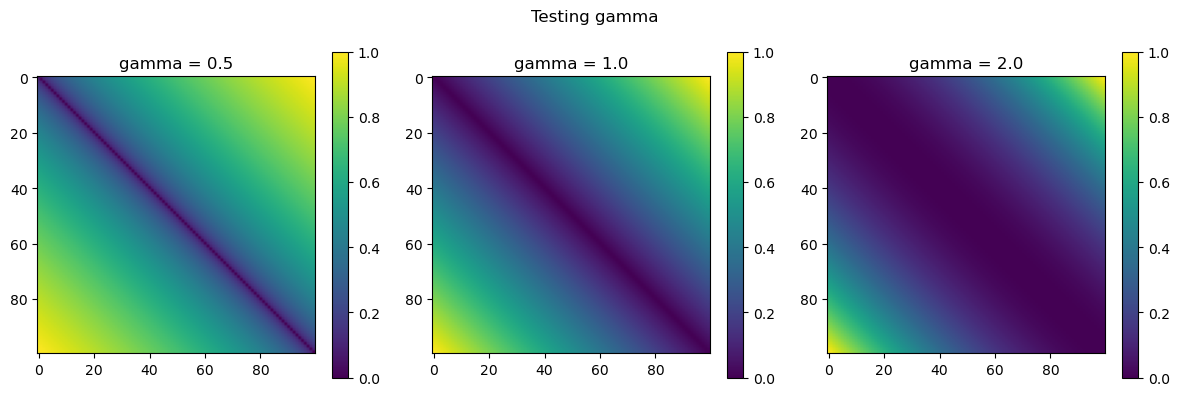

In [38]:
### Visualization Gamma ###
n_vis = 100
M_vis = np.ones((n_vis, n_vis))

fig, axs = plt.subplots(1, 3, figsize=(12, 4))

for ax, g in zip(axs, [0.5, 1.0, 2.0]):
    w = dist_weights(M_vis, gamma=g)
    im = ax.imshow(w)
    ax.set_title(f'gamma = {g}')
    plt.colorbar(im, ax=ax)

plt.suptitle("Testing gamma")
plt.tight_layout()

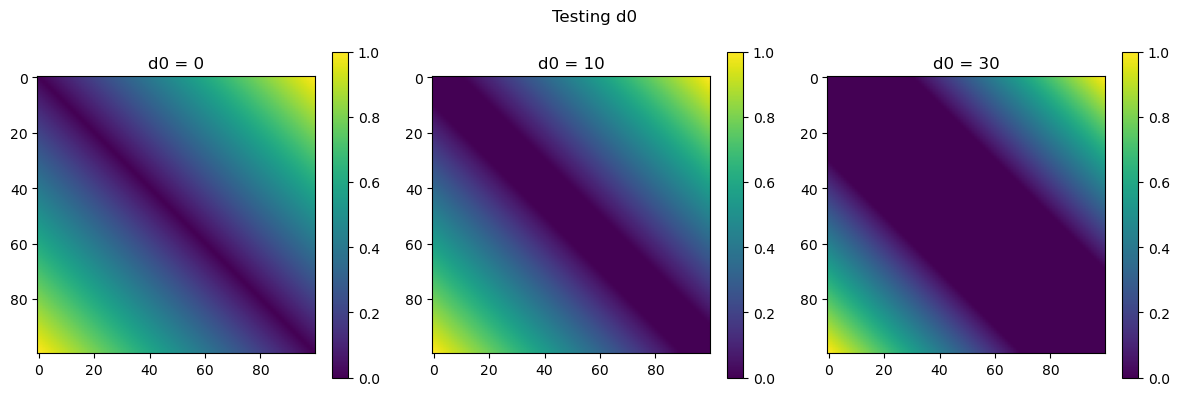

In [36]:
### Visualization d0 ###
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

for ax, d in zip(axs, [0, 10, 30]):
    w = dist_weights(M_vis, d0=d)
    im = ax.imshow(w)
    ax.set_title(f'd0 = {d}')
    plt.colorbar(im, ax=ax)

plt.suptitle("Testing d0")
plt.tight_layout()

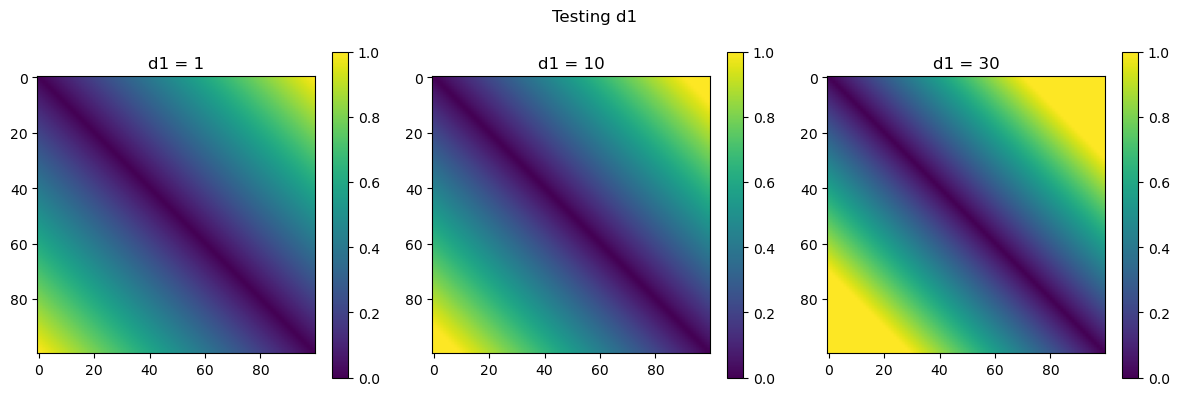

In [37]:
### Visualization d1 ###
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

for ax, d in zip(axs, [1, 10, 30]):
    w = dist_weights(M_vis, d1=d)
    im = ax.imshow(w)
    ax.set_title(f'd1 = {d}')
    plt.colorbar(im, ax=ax)

plt.suptitle("Testing d1")
plt.tight_layout()